# Road Accident Analysis - Exploratory Data Analysis (EDA)

## Project Objective

This notebook performs Exploratory Data Analysis (EDA) on the cleaned
2025 UK road accident dataset.

The analysis focuses on identifying patterns and relationships in:

- Accident severity
- Time and day of accidents
- Monthly accident trends
- Road types
- Speed limits
- Weather conditions
- Light conditions
- Road surface conditions
- Urban and rural areas
- Number of vehicles
- Number of casualties

The goal is to understand when, where, and under which conditions
road accidents are more frequent and severe.

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


### Load cleaned dataset

In [2]:
df = pd.read_csv("../03_Cleaned_Data/road_accidents_2025_cleaned.csv")

print("Cleaned dataset loaded successfully.")

Cleaned dataset loaded successfully.


### Check dataset

In [3]:
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape: (101525, 60)
Rows: 101525
Columns: 60


### Preview data

In [4]:
df.head()

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,part_of_day,day_type,location_available,collision_severity_label,day_name,road_type_label,light_conditions_label,weather_conditions_label,road_surface_conditions_label,urban_rural_label
0,202517H102225,2025,17H102225,449216.0,534979.0,-1.23770,54.70743,17,2,3,...,Afternoon,Weekday,Available,Serious,Wednesday,Dual carriageway,Daylight,Fine - no high winds,Dry,Rural
1,2025070815222,2025,070815222,363808.0,389192.0,-2.54576,53.39831,7,3,2,...,Evening,Weekday,Available,Slight,Friday,One way street,Darkness - lights lit,Raining - high winds,Wet or damp,Urban
2,2025070937984,2025,070937984,362413.0,389071.0,-2.56673,53.39712,7,2,2,...,Night,Weekend,Available,Serious,Saturday,Single carriageway,Darkness - lighting unknown,Unknown,Unknown,Urban
3,2025041687395,2025,041687395,368238.0,427802.0,-2.48308,53.74562,4,2,1,...,Night,Weekday,Available,Serious,Tuesday,Single carriageway,Darkness - lights lit,Fine - no high winds,Wet or damp,Urban
4,2025161555094,2025,161555094,510792.0,432167.0,-0.32035,53.77406,16,3,2,...,Morning,Weekday,Available,Slight,Thursday,Single carriageway,Daylight,Fine - no high winds,Dry,Urban


### Dataset information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101525 entries, 0 to 101524
Data columns (total 60 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   101525 non-null  str    
 1   collision_year                                    101525 non-null  int64  
 2   collision_ref_no                                  101525 non-null  str    
 3   location_easting_osgr                             101523 non-null  float64
 4   location_northing_osgr                            101523 non-null  float64
 5   longitude                                         101523 non-null  float64
 6   latitude                                          101523 non-null  float64
 7   police_force                                      101525 non-null  int64  
 8   collision_severity                                101525 non-null  int64  
 9   number_of_vehic

### Statistical Summary

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
collision_year,101525.0,2025.000000,0.000000,2025.00000,2025.00000,2025.00000,2025.00000,2.025000e+03
location_easting_osgr,101523.0,454027.068812,92739.506456,71253.00000,392107.50000,458353.00000,529150.50000,6.551260e+05
location_northing_osgr,101523.0,276459.222127,145214.997315,10237.00000,175365.00000,222829.00000,381393.50000,1.162591e+06
longitude,101523.0,-1.223959,1.356983,-7.41772,-2.11870,-1.13891,-0.13791,1.755590e+00
latitude,101523.0,52.375658,1.308239,49.91253,51.46446,51.88864,53.32586,6.034525e+01
police_force,101525.0,27.962522,24.075091,1.00000,5.00000,23.00000,45.00000,9.900000e+01
collision_severity,101525.0,2.723250,0.478315,1.00000,2.00000,3.00000,3.00000,3.000000e+00
number_of_vehicles,101525.0,1.811849,0.689631,1.00000,1.00000,2.00000,2.00000,1.700000e+01
number_of_casualties,101525.0,1.259621,0.816679,1.00000,1.00000,1.00000,1.00000,1.420000e+02
day_of_week,101525.0,4.126097,1.926299,1.00000,2.00000,4.00000,6.00000,7.000000e+00


### Categorical summary

In [7]:
# Categorical Summary

df.describe(include=[str]).T

,count,unique,top,freq
collision_index,101525,101525,202517H102225,1
collision_ref_no,101525,101525,17H102225,1
date,101525,365,2025-12-19,412
time,101525,1440,17:00,891
local_authority_ons_district,101525,351,E08000025,2307
local_authority_highway,101525,208,E10000016,2957
local_authority_highway_current,101525,208,E10000016,2957
lsoa_of_accident_location,101525,27179,-1,4107
time_clean,101525,1440,17:00:00,891
month_name,101525,12,November,9188


# Basic Analysis

## 1. Accident Severity Analysis

This section examines the distribution of accident severity levels.

Understanding severity helps identify how many accidents resulted in
fatal, serious, or slight injuries.

In [8]:
severity_counts = df["collision_severity_label"].value_counts()
severity_counts

collision_severity_label
Slight     74881
Serious    25191
Fatal       1453
Name: count, dtype: int64

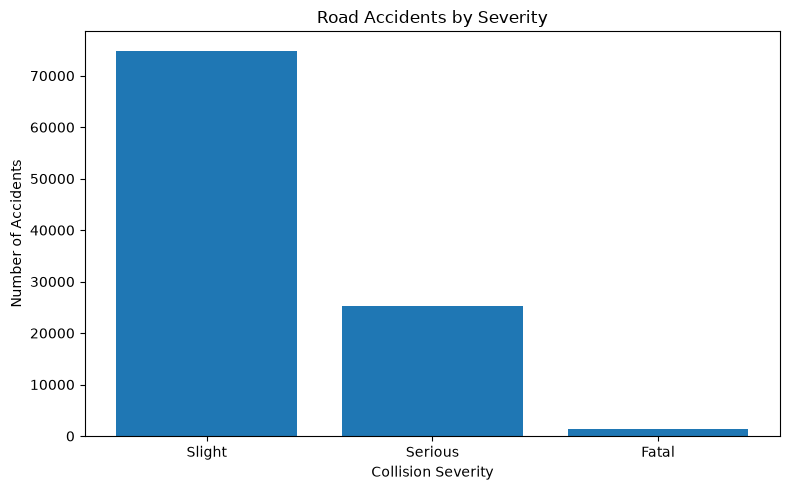

In [9]:
plt.figure(figsize=(8, 5))

severity_order = ["Slight", "Serious", "Fatal"]

severity_counts = (
    df["collision_severity_label"]
    .value_counts()
    .reindex(severity_order)
)

plt.bar(
    severity_counts.index,
    severity_counts.values
)

plt.title("Road Accidents by Severity")
plt.xlabel("Collision Severity")
plt.ylabel("Number of Accidents")

plt.tight_layout()
plt.show()

In [10]:
# Severity Percentage
severity_percentage = (
    df["collision_severity_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

severity_percentage

collision_severity_label
Slight     73.76
Serious    24.81
Fatal       1.43
Name: proportion, dtype: float64

## 2. Monthly Accident Analysis

This section examines how accident frequency changes throughout the year.

In [11]:
monthly_accidents = (
    df.groupby(["month", "month_name"])
      .size()
      .reset_index(name="accident_count")
      .sort_values("month")
)

monthly_accidents

,month,month_name,accident_count
0,1,January,8163
1,2,February,7155
2,3,March,8451
3,4,April,8315
4,5,May,8849
5,6,June,8725
6,7,July,8762
7,8,August,8318
8,9,September,8581
9,10,October,8613


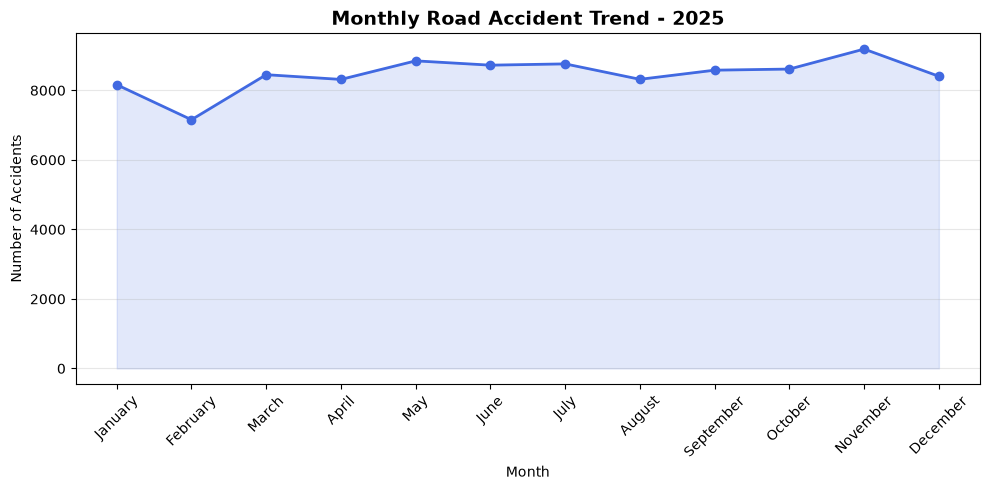

In [12]:
# Monthly Trend
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_accidents["month_name"],
    monthly_accidents["accident_count"],
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.fill_between(
    range(len(monthly_accidents)),
    monthly_accidents["accident_count"],
    alpha=0.15,
    color="royalblue"
)

plt.title(
    "Monthly Road Accident Trend - 2025",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Day of Week

In [13]:
# Accidents by day
day_order = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

day_counts = (
    df["day_name"]
    .value_counts()
    .reindex(day_order)
)

day_counts

day_name
Sunday       11197
Monday       14309
Tuesday      14880
Wednesday    15369
Thursday     15304
Friday       16811
Saturday     13655
Name: count, dtype: int64

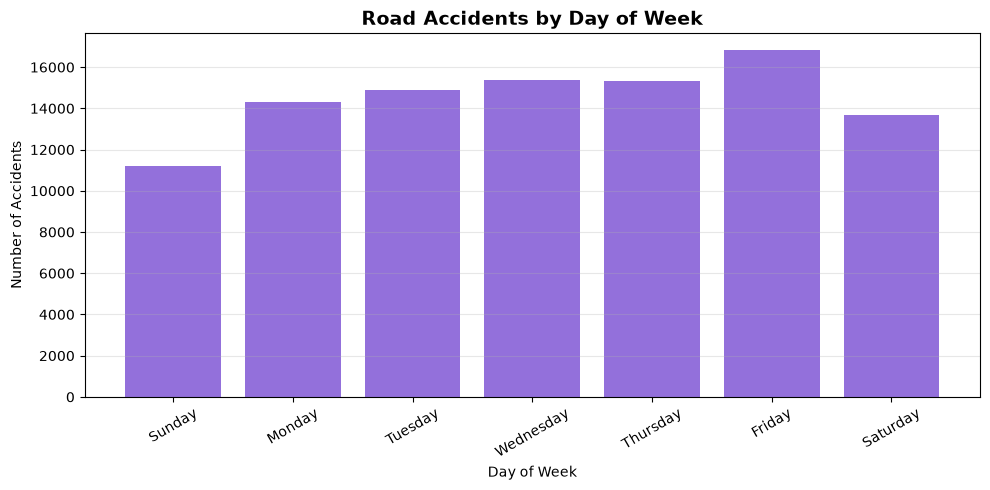

In [14]:
# Day-of-Week Chart
plt.figure(figsize=(10, 5))

plt.bar(
    day_counts.index,
    day_counts.values,
    color="mediumpurple"
)

plt.title(
    "Road Accidents by Day of Week",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Part of Day

In [15]:
# Part of day
part_of_day_counts = df["part_of_day"].value_counts()
part_of_day_counts

part_of_day
Afternoon    35488
Morning      27795
Evening      25246
Night        12996
Name: count, dtype: int64

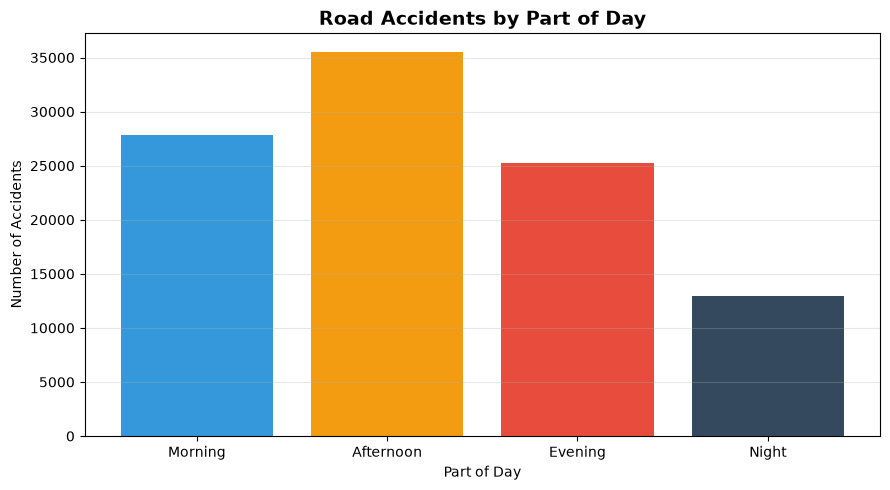

In [16]:
# Part-of-Day Chart

# Define the order of categories
part_order = ["Morning", "Afternoon", "Evening", "Night"]

# Get accident counts in the required order
part_of_day_values = [
    part_of_day_counts.get("Morning", 0),
    part_of_day_counts.get("Afternoon", 0),
    part_of_day_counts.get("Evening", 0),
    part_of_day_counts.get("Night", 0)
]

# Create chart
plt.figure(figsize=(9, 5))

plt.bar(
    part_order,
    part_of_day_values,
    color=["#3498DB", "#F39C12", "#E74C3C", "#34495E"]
)

# Title and labels
plt.title(
    "Road Accidents by Part of Day",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Part of Day")
plt.ylabel("Number of Accidents")

# Grid
plt.grid(axis="y", alpha=0.3)

# Display
plt.tight_layout()
plt.show()

## 5. Hourly Trend

In [17]:
# Accidents by Hour
hourly_accidents = (
    df.groupby("hour")
      .size()
      .reset_index(name="accident_count")
)

hourly_accidents.head()

,hour,accident_count
0,0,1525
1,1,1032
2,2,789
3,3,651
4,4,634


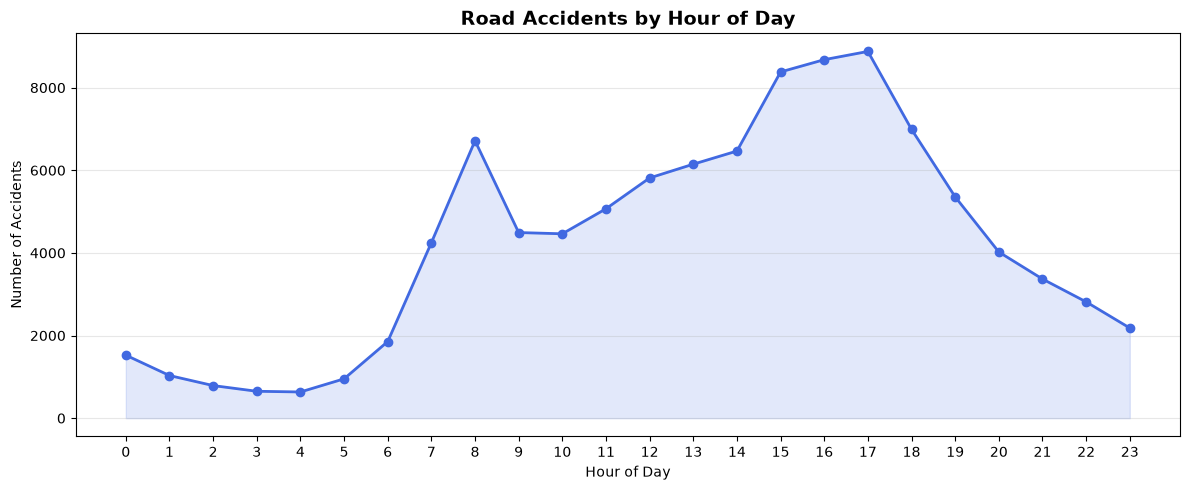

In [18]:
# Hourly Accident Trend
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_accidents["hour"],
    hourly_accidents["accident_count"],
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.fill_between(
    hourly_accidents["hour"],
    hourly_accidents["accident_count"],
    alpha=0.15,
    color="royalblue"
)

plt.title("Road Accidents by Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")

plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Road Characteristics Analysis

This section examines accident patterns across different road types
and speed limits.

The objective is to understand whether certain road characteristics
are associated with a higher number of accidents.

## 6. Road type

In [19]:
# Road Type Distribution
road_type_counts = (
    df["road_type_label"]
    .value_counts()
    .sort_values(ascending=False)
)

road_type_counts

road_type_label
Single carriageway    74150
Dual carriageway      14610
Roundabout             6795
One way street         2398
Unknown                1953
Slip road              1619
Name: count, dtype: int64

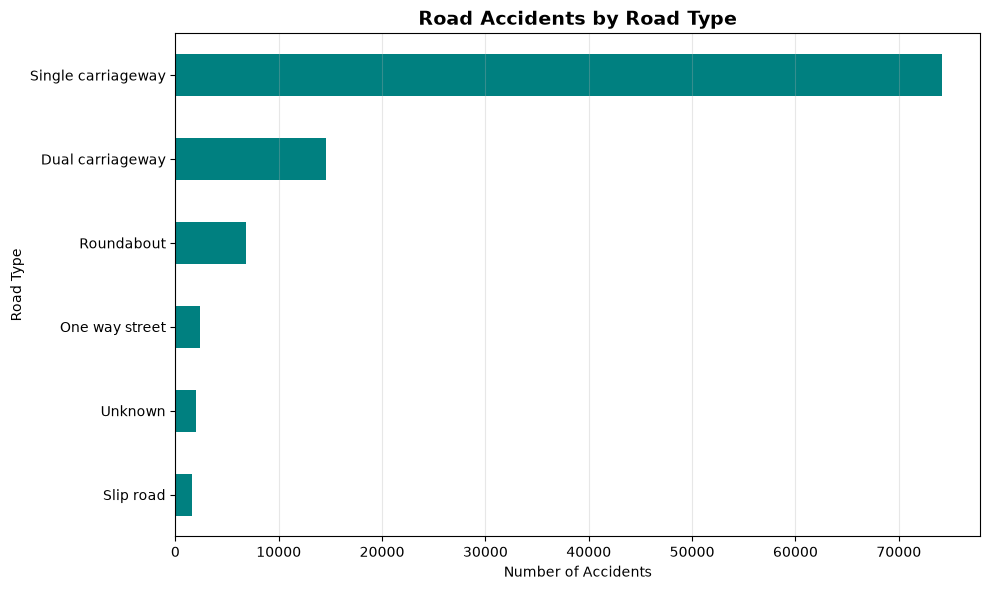

In [20]:
# Road Type Chart
plt.figure(figsize=(10, 6))

road_type_counts.sort_values().plot(
    kind="barh",
    color="teal"
)

plt.title(
    "Road Accidents by Road Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("Road Type")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Speed limit

In [21]:
# Speed Limit Distribution
speed_counts = (
    df["speed_limit"]
    .value_counts()
    .sort_index()
)

speed_counts

speed_limit
20    20045
30    49673
40     8886
50     4612
60    12709
70     5600
Name: count, dtype: int64

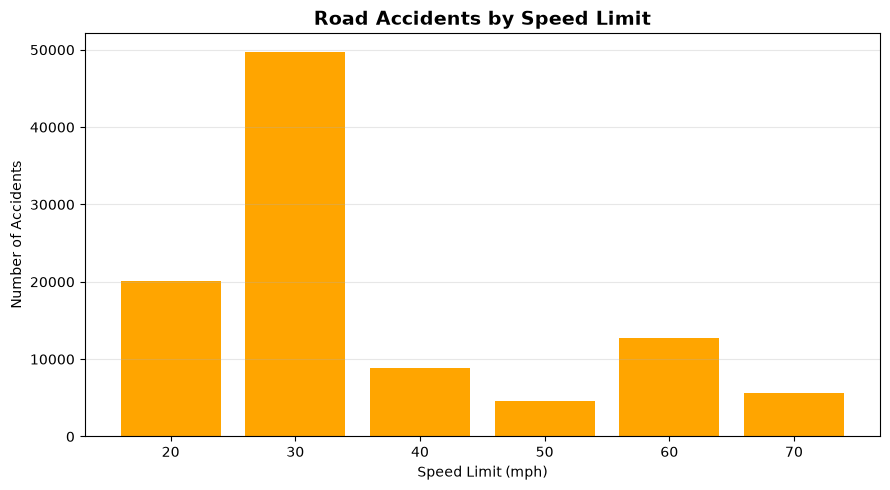

In [22]:
# Speed Limit Chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    speed_counts.index.astype(str),
    speed_counts.values,
    color="orange"
)

plt.title(
    "Road Accidents by Speed Limit",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Speed Limit (mph)")
plt.ylabel("Number of Accidents")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Environmental Conditions Analysis

This section analyzes accidents according to:

- Weather conditions
- Light conditions
- Road surface conditions

These factors can help identify environmental conditions commonly
present when accidents occur.

## 8. Weather condition

In [23]:
# Weather Conditions
weather_counts = (
    df["weather_conditions_label"]
    .value_counts()
    .sort_values(ascending=False)
)

weather_counts

weather_conditions_label
Fine - no high winds       83405
Raining - no high winds    10230
Other                       3314
Unknown                     2385
Raining - high winds         880
Fine - high winds            715
Fog or mist                  342
Snowing - no high winds      235
Snowing - high winds          19
Name: count, dtype: int64

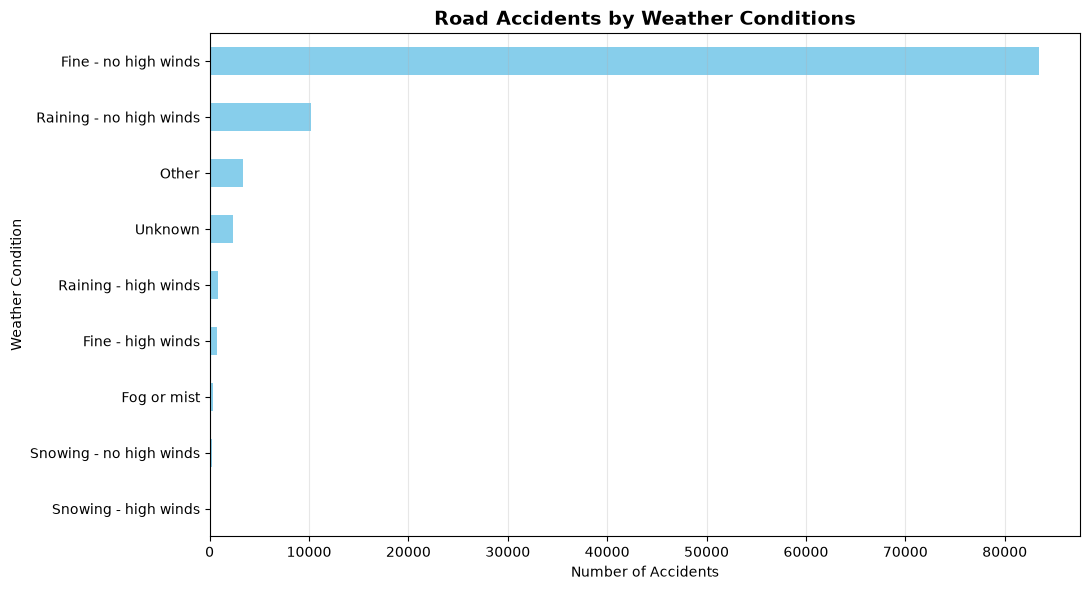

In [24]:
# Weather Chart
plt.figure(figsize=(11, 6))

weather_counts.sort_values().plot(
    kind="barh",
    color="skyblue"
)

plt.title(
    "Road Accidents by Weather Conditions",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 9. light Condition

In [25]:
# Light Conditions
light_counts = (
    df["light_conditions_label"]
    .value_counts()
    .sort_values(ascending=False)
)

light_counts

light_conditions_label
Daylight                       72814
Darkness - lights lit          20705
Darkness - no lighting          5682
Darkness - lighting unknown     1588
Darkness - lights unlit          720
Unknown                           16
Name: count, dtype: int64

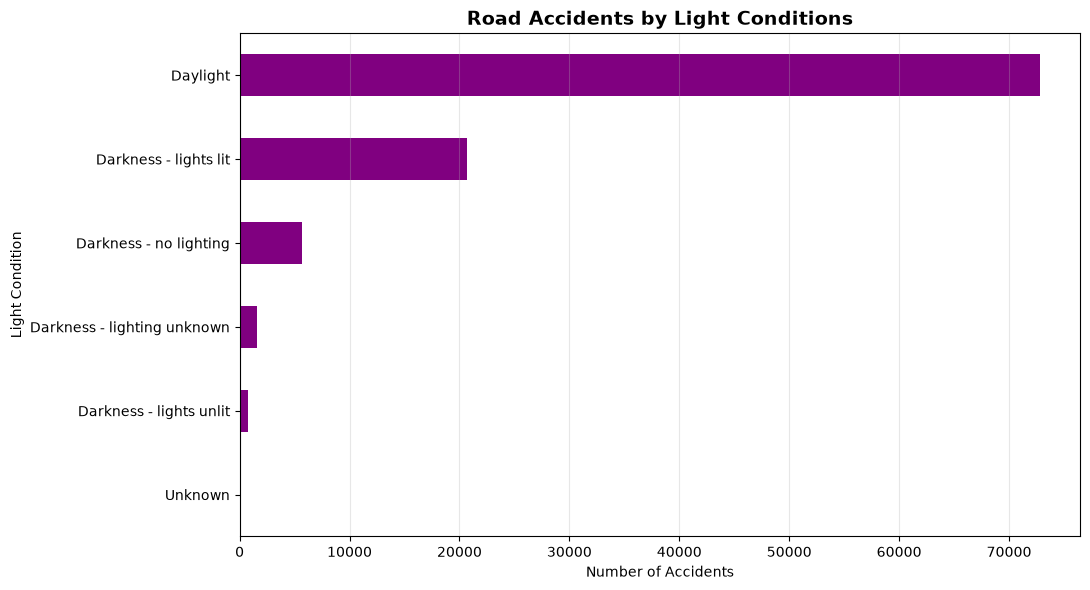

In [26]:
# Light Conditions Chart
plt.figure(figsize=(11, 6))

light_counts.sort_values().plot(
    kind="barh",
    color="purple"
)

plt.title(
    "Road Accidents by Light Conditions",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("Light Condition")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Road Surface

In [27]:
# Road Surface Conditions
surface_counts = (
    df["road_surface_conditions_label"]
    .value_counts()
    .sort_values(ascending=False)
)

surface_counts

road_surface_conditions_label
Dry                    75679
Wet or damp            22312
Unknown                 1976
Frost or ice            1261
Flood over 3cm deep      151
Snow                     146
Name: count, dtype: int64

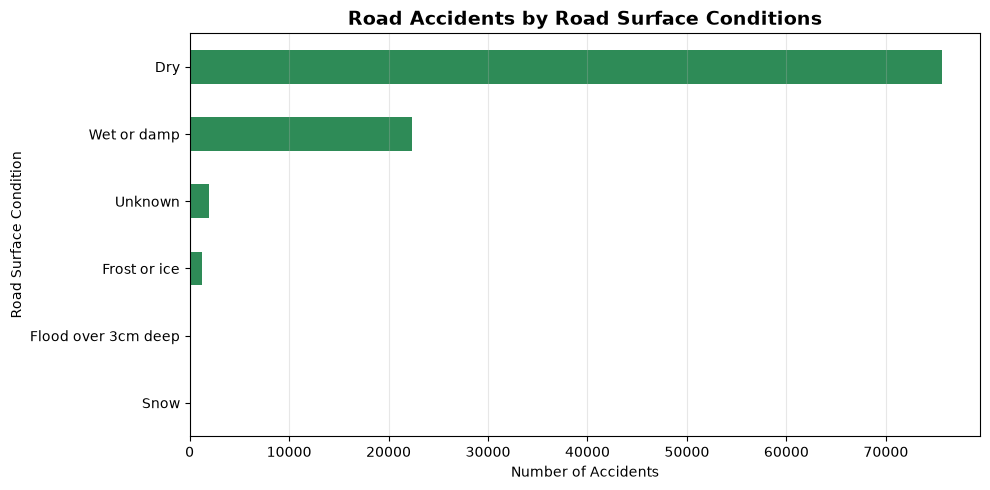

In [28]:
# Road Surface Chart
plt.figure(figsize=(10, 5))

surface_counts.sort_values().plot(
    kind="barh",
    color="seagreen"
)

plt.title(
    "Road Accidents by Road Surface Conditions",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("Road Surface Condition")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# Location
## 11. Urban vs Rural Analysis

This section compares accident frequency between urban and rural areas.

In [29]:
# Urban/Rural Counts
urban_rural_counts = (
    df["urban_rural_label"]
    .value_counts()
)

urban_rural_counts

urban_rural_label
Urban      67148
Rural      34373
Unknown        4
Name: count, dtype: int64

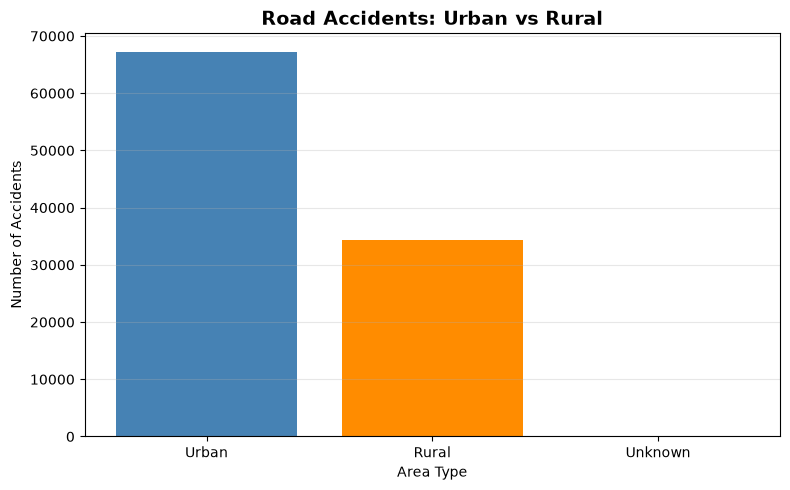

In [30]:
# Urban/Rural Chart 
plt.figure(figsize=(8, 5))

plt.bar(
    urban_rural_counts.index,
    urban_rural_counts.values,
    color=["steelblue", "darkorange", "gray"]
)

plt.title(
    "Road Accidents: Urban vs Rural",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Area Type")
plt.ylabel("Number of Accidents")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Accident imapact
This section examines the number of vehicles and casualties involved
in road accidents.

It also helps identify whether accidents involving multiple vehicles
tend to have more casualties.

## 12. Number of vehicles

In [31]:
# Number of Vehicles
vehicle_counts = (
    df["number_of_vehicles"]
    .value_counts()
    .sort_index()
)

vehicle_counts.head(10)

number_of_vehicles
1     30841
2     61869
3      6876
4      1331
5       405
6       109
7        58
8        18
9         7
10        5
Name: count, dtype: int64

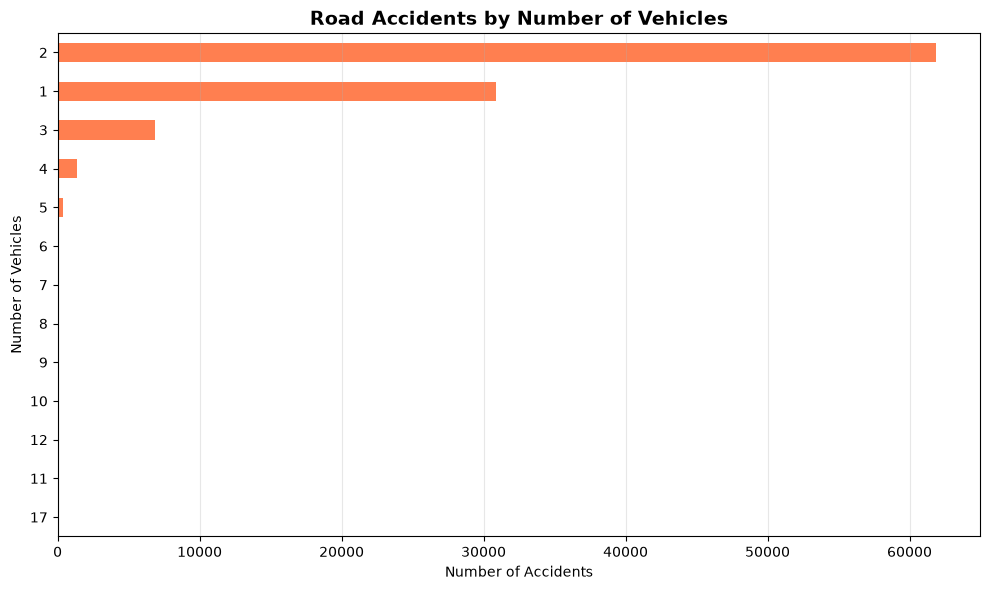

In [32]:
# Vehicle Count Chart
plt.figure(figsize=(10, 6))

vehicle_counts.sort_values().plot(
    kind="barh",
    color="coral"
)

plt.title(
    "Road Accidents by Number of Vehicles",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("Number of Vehicles")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Number of Casualties

In [33]:
# Number of Casualties
casualty_counts = (
    df["number_of_casualties"]
    .value_counts()
    .sort_index()
)

casualty_counts.head(15)

number_of_casualties
1     83317
2     13126
3      3301
4      1178
5       389
6       113
7        46
8        17
9         9
10        9
11        3
12        6
13        1
15        1
17        1
Name: count, dtype: int64

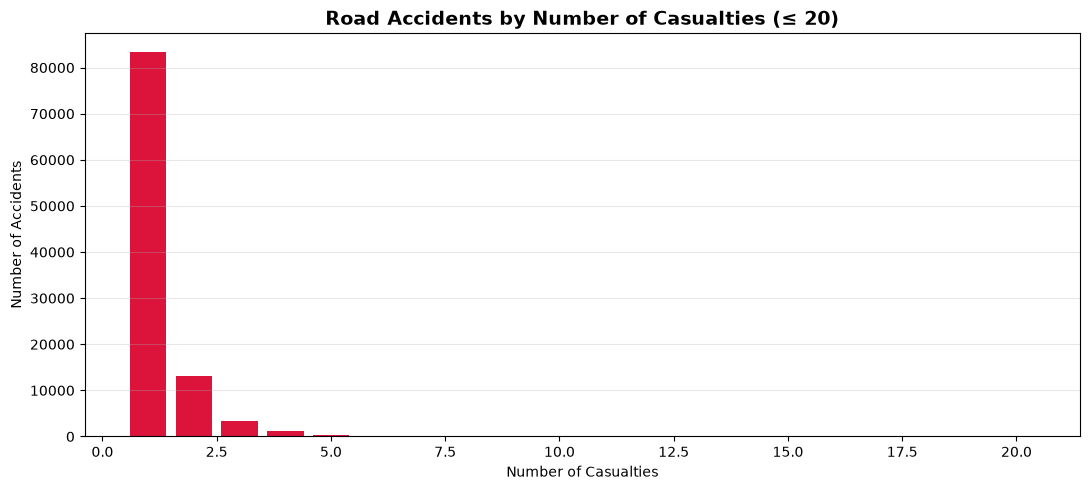

In [34]:
# Casualty Distribution
casualty_visual = (
    df[df["number_of_casualties"] <= 20]
    ["number_of_casualties"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(11, 5))

plt.bar(
    casualty_visual.index,
    casualty_visual.values,
    color="crimson"
)

plt.title(
    "Road Accidents by Number of Casualties (≤ 20)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Casualties")
plt.ylabel("Number of Accidents")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Relationship Analysis

In [35]:
# Vehicles vs Casualties
vehicle_casualty = (
    df.groupby("number_of_vehicles")["number_of_casualties"]
      .mean()
      .reset_index()
)

vehicle_casualty


,number_of_vehicles,number_of_casualties
0,1,1.135080
1,2,1.266644
2,3,1.580134
3,4,1.844478
4,5,1.960494
5,6,2.027523
6,7,1.844828
7,8,1.833333
8,9,1.857143
9,10,1.400000


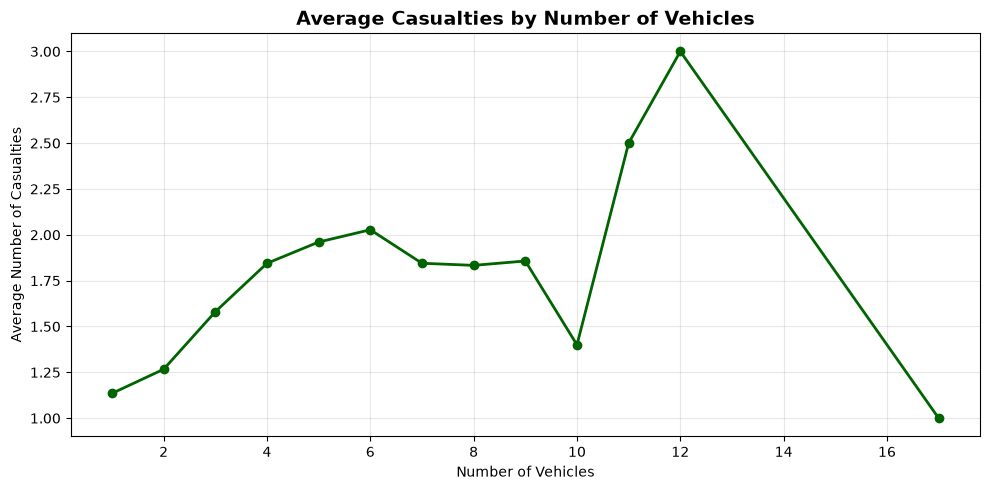

In [36]:
# Vehicles vs Average Casualties
plt.figure(figsize=(10, 5))

plt.plot(
    vehicle_casualty["number_of_vehicles"],
    vehicle_casualty["number_of_casualties"],
    marker="o",
    linewidth=2,
    color="darkgreen"
)

plt.title(
    "Average Casualties by Number of Vehicles",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Vehicles")
plt.ylabel("Average Number of Casualties")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Advanced Severity Analysis
## 15. Severity by day

In [37]:
# Severity by Day of Week
severity_day = pd.crosstab(
    df["day_name"],
    df["collision_severity_label"]
).reindex(day_order)

severity_day

collision_severity_label,Fatal,Serious,Slight
day_name,,,
Sunday,204,2993,8000
Monday,187,3444,10678
Tuesday,175,3557,11148
Wednesday,204,3713,11452
Thursday,195,3748,11361
Friday,248,4100,12463
Saturday,240,3636,9779


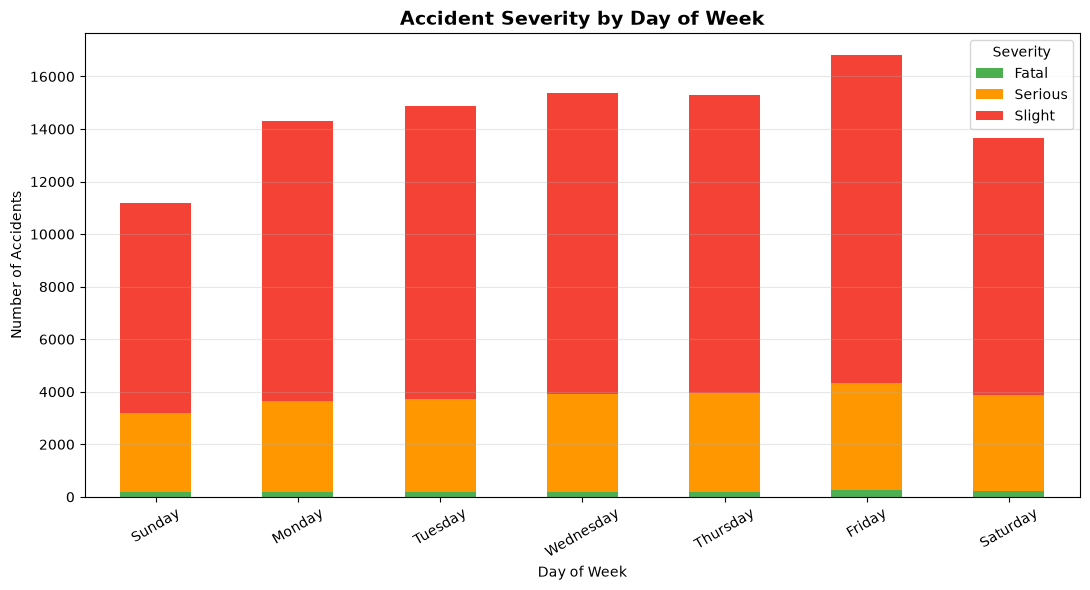

In [38]:
# Severity by Day of Week Chart
severity_day.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=["#4CAF50", "#FF9800", "#F44336"]
)

plt.title(
    "Accident Severity by Day of Week",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30)
plt.legend(title="Severity")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 16. Severity by part of day

In [39]:
# Severity by Part of Day
severity_part = pd.crosstab(
    df["part_of_day"],
    df["collision_severity_label"]
).reindex(["Morning", "Afternoon", "Evening", "Night"])

severity_part

collision_severity_label,Fatal,Serious,Slight
part_of_day,,,
Morning,350,6401,21044
Afternoon,426,8730,26332
Evening,328,6359,18559
Night,349,3701,8946


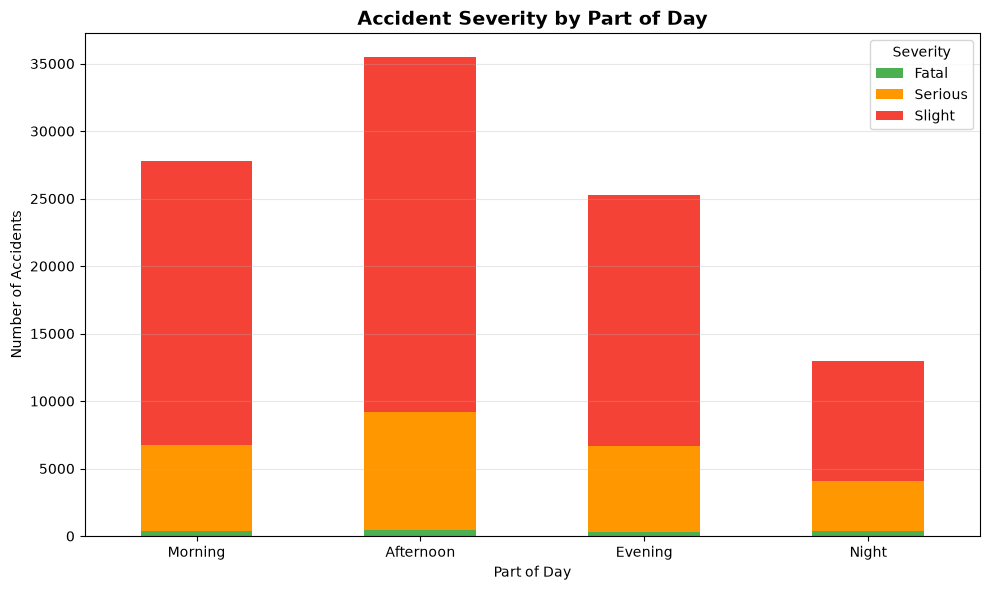

In [40]:
# Severity by Part of Day Chart
severity_part.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#4CAF50", "#FF9800", "#F44336"]
)

plt.title(
    "Accident Severity by Part of Day",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Part of Day")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.legend(title="Severity")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 17. Weather vs severity

In [41]:
# Weather vs Severity
weather_severity = pd.crosstab(
    df["weather_conditions_label"],
    df["collision_severity_label"]
)

weather_severity

collision_severity_label,Fatal,Serious,Slight
weather_conditions_label,,,
Fine - high winds,17,213,485
Fine - no high winds,1248,21088,61069
Fog or mist,11,99,232
Other,21,668,2625
Raining - high winds,13,234,633
Raining - no high winds,138,2528,7564
Snowing - high winds,0,2,17
Snowing - no high winds,2,65,168
Unknown,3,294,2088


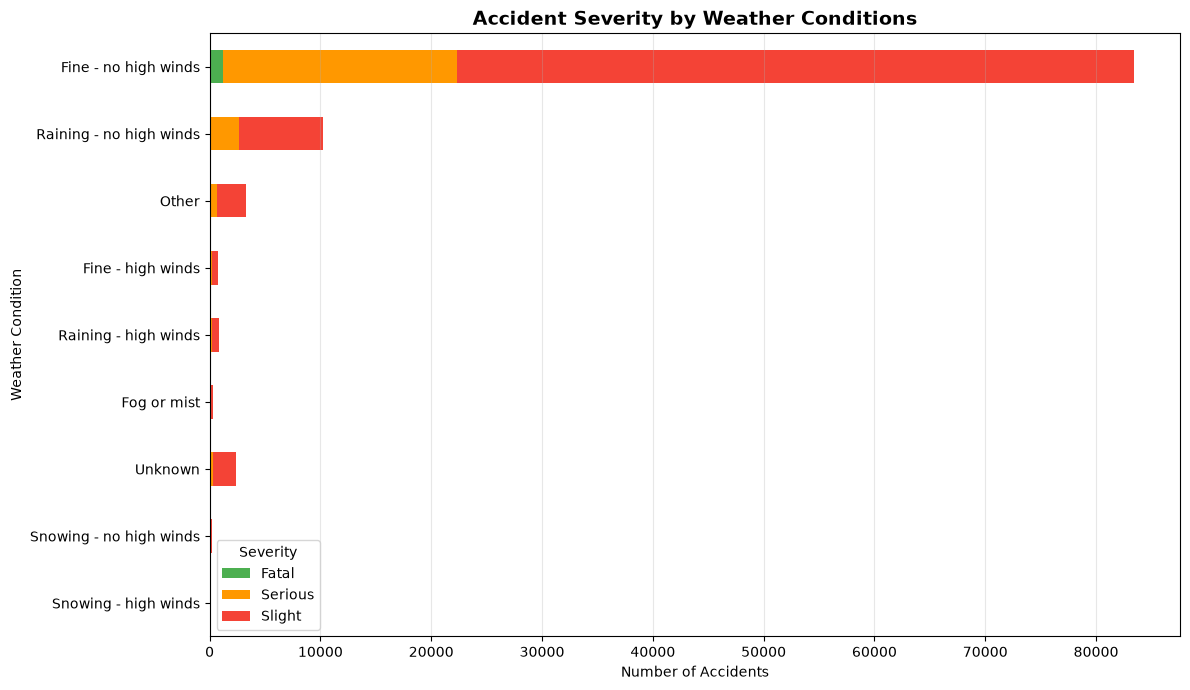

In [42]:
# Weather vs Severity
weather_severity.sort_values(
    by="Fatal",
    ascending=True
).plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7),
    color=["#4CAF50", "#FF9800", "#F44336"]
)

plt.title(
    "Accident Severity by Weather Conditions",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")
plt.legend(title="Severity")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Severity rate by speed limit

In [43]:
# Severity Rate by Speed Limit
severity_rate_speed = (
    df.assign(
        severe=df["collision_severity_label"].isin(
            ["Serious", "Fatal"]
        )
    )
    .groupby("speed_limit")["severe"]
    .mean()
    .mul(100)
    .reset_index(name="severe_accident_rate")
)

severity_rate_speed

,speed_limit,severe_accident_rate
0,20,22.354702
1,30,24.808246
2,40,27.267612
3,50,29.575022
4,60,36.375797
5,70,25.535714


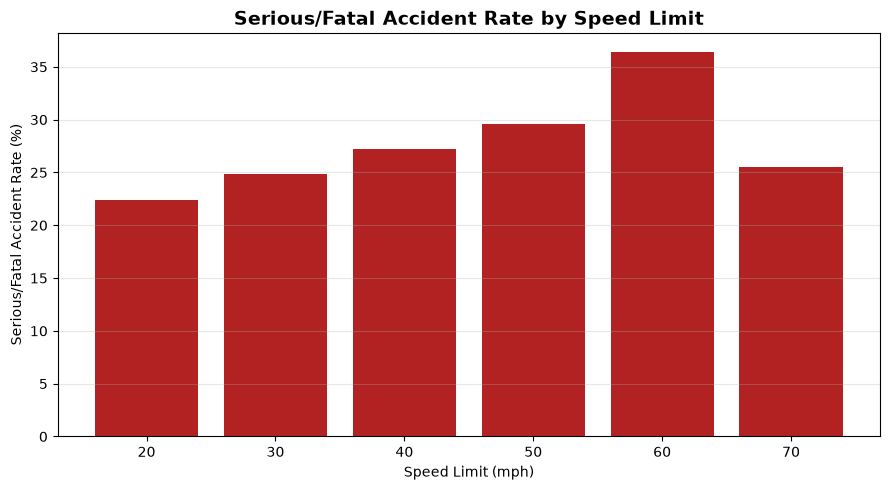

In [44]:
# Severity Rate Chart
plt.figure(figsize=(9, 5))

plt.bar(
    severity_rate_speed["speed_limit"].astype(str),
    severity_rate_speed["severe_accident_rate"],
    color="firebrick"
)

plt.title(
    "Serious/Fatal Accident Rate by Speed Limit",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Speed Limit (mph)")
plt.ylabel("Serious/Fatal Accident Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 19. Urban/Rural vs severity

In [45]:
# Urban/Rural Severity
urban_severity = pd.crosstab(
    df["urban_rural_label"],
    df["collision_severity_label"]
)

urban_severity

collision_severity_label,Fatal,Serious,Slight
urban_rural_label,,,
Rural,932,9682,23759
Unknown,0,2,2
Urban,521,15507,51120


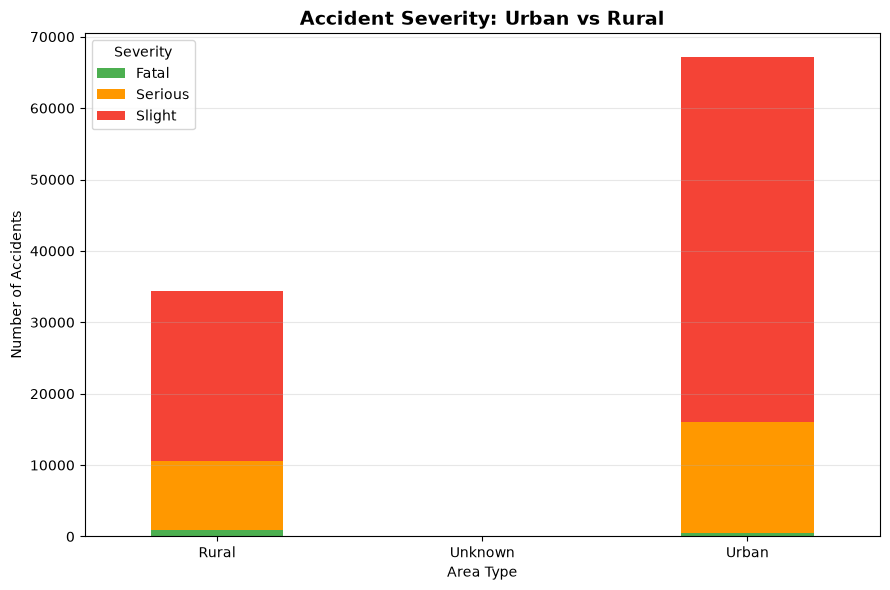

In [46]:
# Urban/Rural Severity
urban_severity.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6),
    color=["#4CAF50", "#FF9800", "#F44336"]
)

plt.title(
    "Accident Severity: Urban vs Rural",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Area Type")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.legend(title="Severity")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 20. Light vs severity

In [47]:
# Light Condition vs Severity
light_severity = pd.crosstab(
    df["light_conditions_label"],
    df["collision_severity_label"]
)

light_severity

collision_severity_label,Fatal,Serious,Slight
light_conditions_label,,,
Darkness - lighting unknown,16,356,1216
Darkness - lights lit,267,5287,15151
Darkness - lights unlit,19,189,512
Darkness - no lighting,268,1794,3620
Daylight,883,17561,54370
Unknown,0,4,12


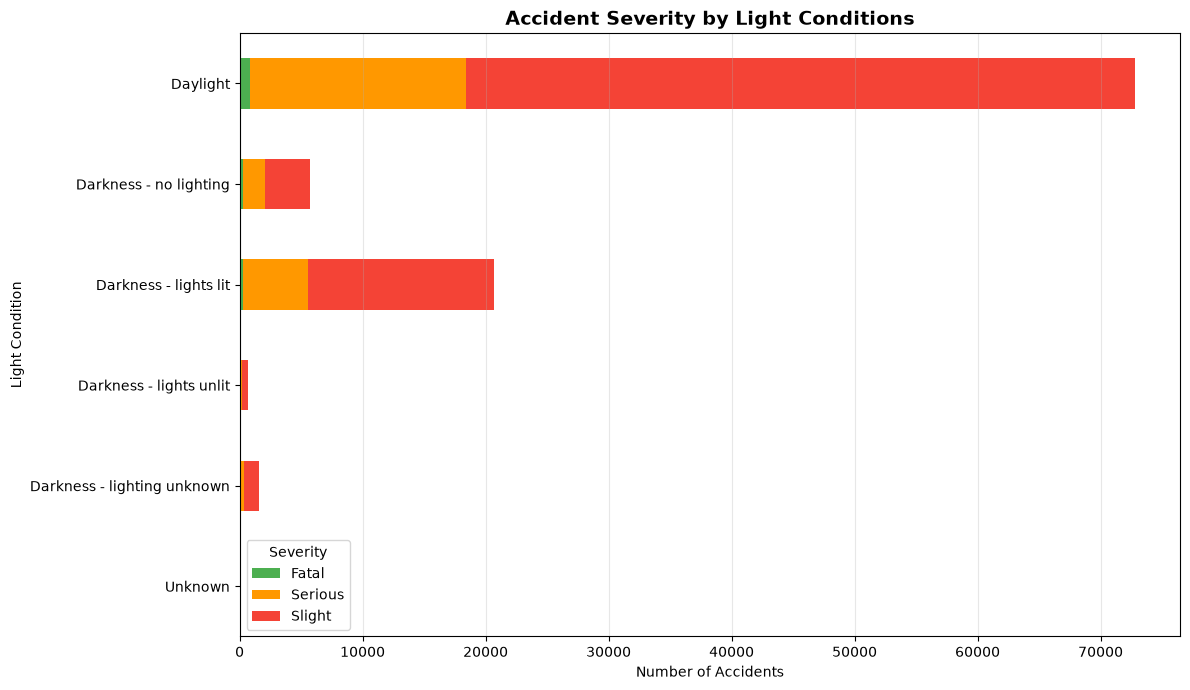

In [48]:
# Light Condition vs Severity Chart
light_severity.sort_values(
    by="Fatal",
    ascending=True
).plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7),
    color=["#4CAF50", "#FF9800", "#F44336"]
)

plt.title(
    "Accident Severity by Light Conditions",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("Light Condition")
plt.legend(title="Severity")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 21. Monthly severity trend

In [49]:
# Monthly Severity Trend
monthly_severity = (
    df.groupby(["month", "month_name", "collision_severity_label"])
      .size()
      .reset_index(name="accident_count")
)

monthly_severity.head()

,month,month_name,collision_severity_label,accident_count
0,1,January,Fatal,99
1,1,January,Serious,1867
2,1,January,Slight,6197
3,2,February,Fatal,87
4,2,February,Serious,1669


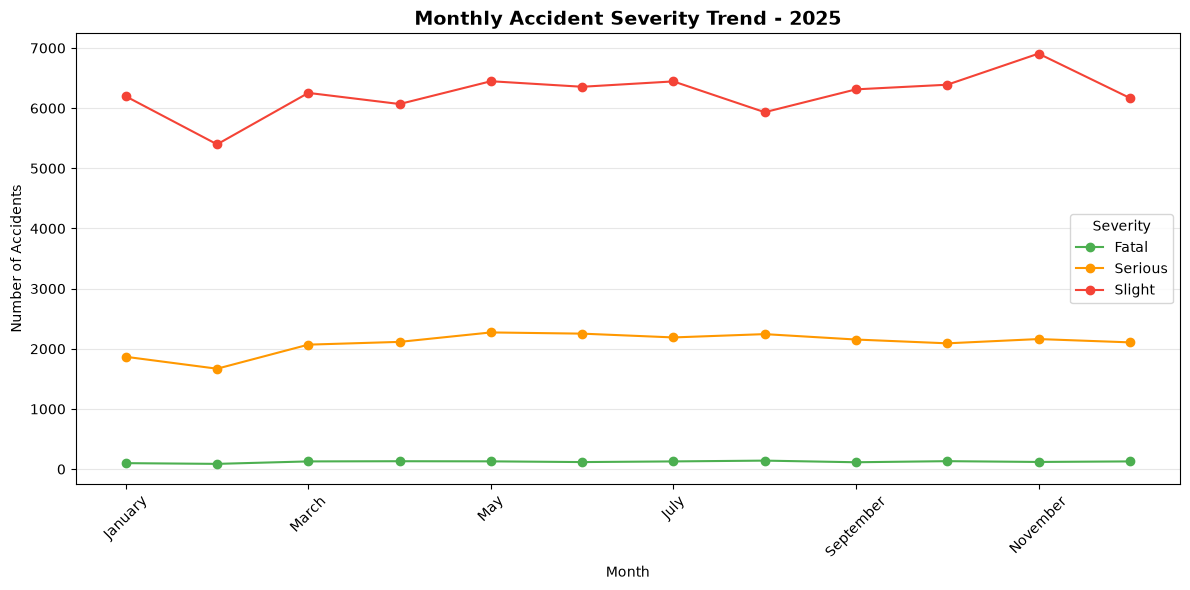

In [50]:
# Monthly Severity Chart
monthly_severity_pivot = (
    monthly_severity
    .pivot(
        index="month_name",
        columns="collision_severity_label",
        values="accident_count"
    )
    .reindex(monthly_accidents["month_name"])
)

monthly_severity_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6),
    color=["#4CAF50", "#FF9800", "#F44336"]
)

plt.title(
    "Monthly Accident Severity Trend - 2025",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Additional Severity Analysis

This section examines how accident severity varies across different
road, environmental, and time-related conditions.

The analysis focuses on identifying patterns associated with
Slight, Serious, and Fatal collisions.

> Note: These analyses identify associations and patterns in the data.
> They do not establish that a particular factor directly causes
> accident severity.

## 22. Severity by Road Type

In [51]:
#  Severity by Road Type
severity_road = pd.crosstab(
    df["road_type_label"],
    df["collision_severity_label"]
)

severity_road

collision_severity_label,Fatal,Serious,Slight
road_type_label,,,
Dual carriageway,268,3320,11022
One way street,6,487,1905
Roundabout,43,1280,5472
Single carriageway,1119,19588,53443
Slip road,17,307,1295
Unknown,0,209,1744


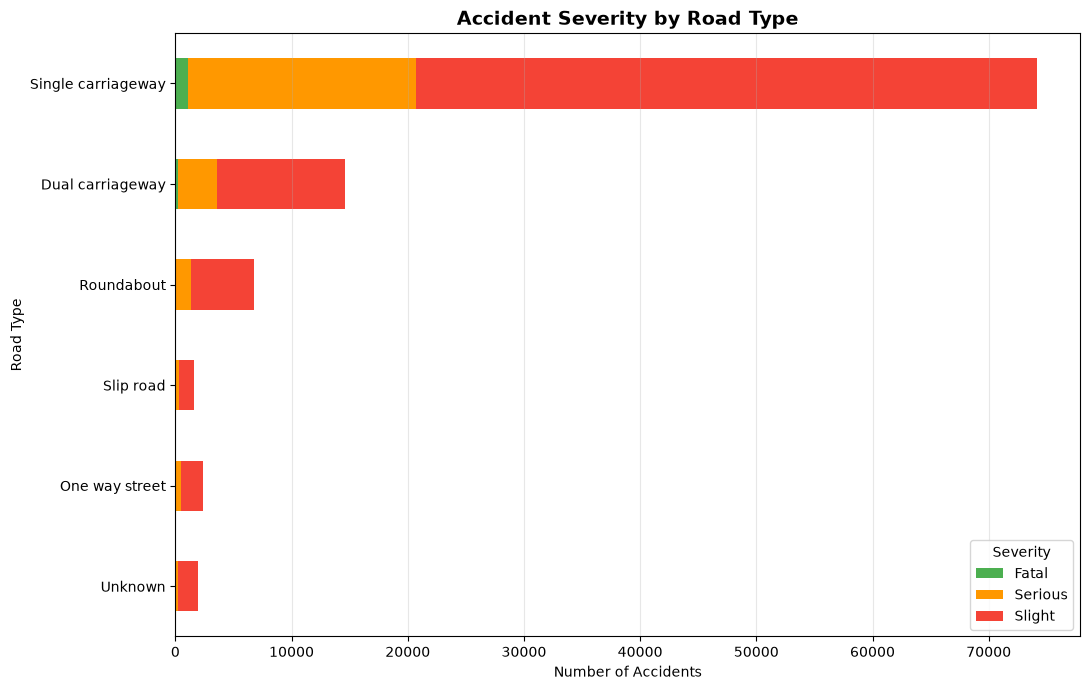

In [52]:
# Severity by Road Type Chart
severity_road.sort_values(
    by="Fatal",
    ascending=True
).plot(
    kind="barh",
    stacked=True,
    figsize=(11, 7),
    color=["#4CAF50", "#FF9800", "#F44336"]
)

plt.title(
    "Accident Severity by Road Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("Road Type")
plt.legend(title="Severity")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 23. Severity by Speed Limit

In [53]:
# Severity by Speed Limit
severity_speed = pd.crosstab(
    df["speed_limit"],
    df["collision_severity_label"]
).sort_index()

severity_speed

collision_severity_label,Fatal,Serious,Slight
speed_limit,,,
20,103,4378,15564
30,428,11895,37350
40,164,2259,6463
50,114,1250,3248
60,470,4153,8086
70,174,1256,4170


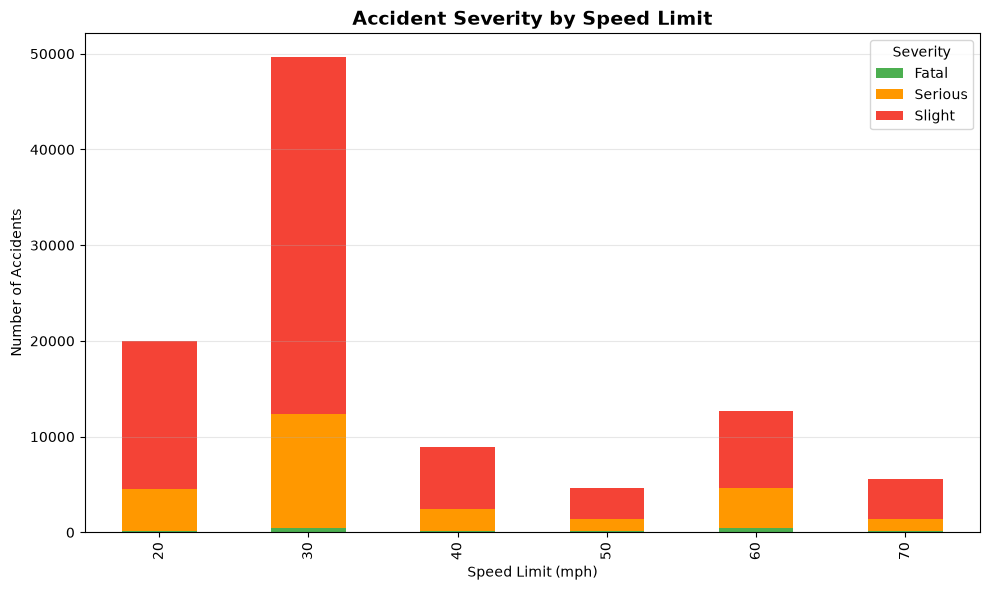

In [54]:
# Severity by Speed Limit Chart
severity_speed.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#4CAF50", "#FF9800", "#F44336"]
)

plt.title(
    "Accident Severity by Speed Limit",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Speed Limit (mph)")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 24. Severity by Road Surface

In [55]:
# Severity by Road Surface
severity_surface = pd.crosstab(
    df["road_surface_conditions_label"],
    df["collision_severity_label"]
)

severity_surface

collision_severity_label,Fatal,Serious,Slight
road_surface_conditions_label,,,
Dry,1078,18851,55750
Flood over 3cm deep,4,45,102
Frost or ice,18,294,949
Snow,3,40,103
Unknown,2,186,1788
Wet or damp,348,5775,16189


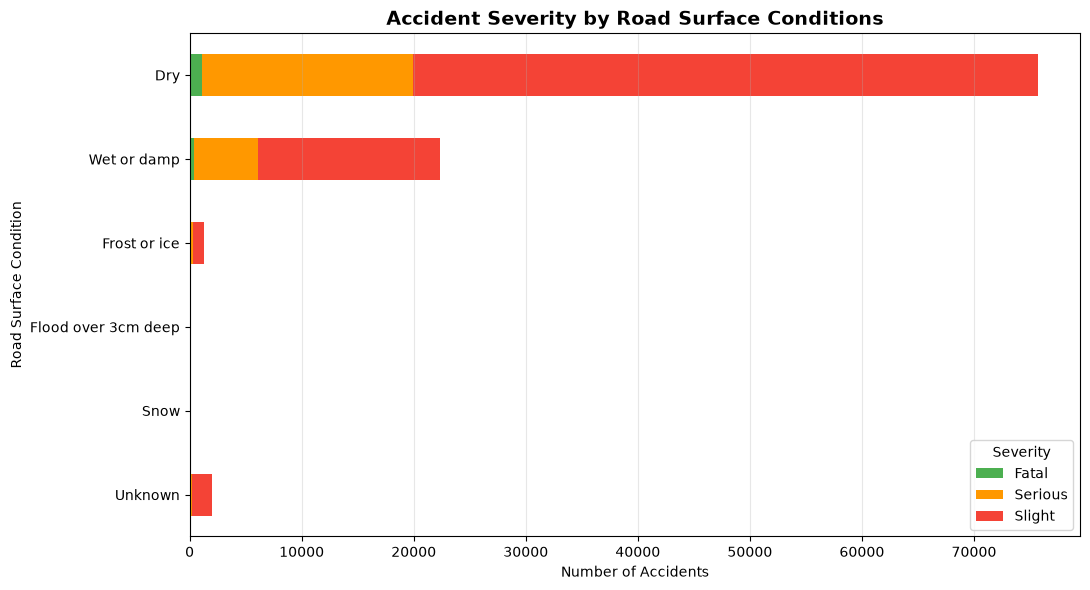

In [56]:
# Severity by Road Surface Chart
severity_surface.sort_values(
    by="Fatal",
    ascending=True
).plot(
    kind="barh",
    stacked=True,
    figsize=(11, 6),
    color=["#4CAF50", "#FF9800", "#F44336"]
)

plt.title(
    "Accident Severity by Road Surface Conditions",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("Road Surface Condition")
plt.legend(title="Severity")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 25. Fatal Accident Rate by Area

In [57]:
# Fatal Accident Rate by Area
fatal_rate_area = (
    df.assign(
        fatal=df["collision_severity_label"] == "Fatal"
    )
    .groupby("urban_rural_label")["fatal"]
    .mean()
    .mul(100)
    .round(2)
)

fatal_rate_area

urban_rural_label
Rural      2.71
Unknown    0.00
Urban      0.78
Name: fatal, dtype: float64

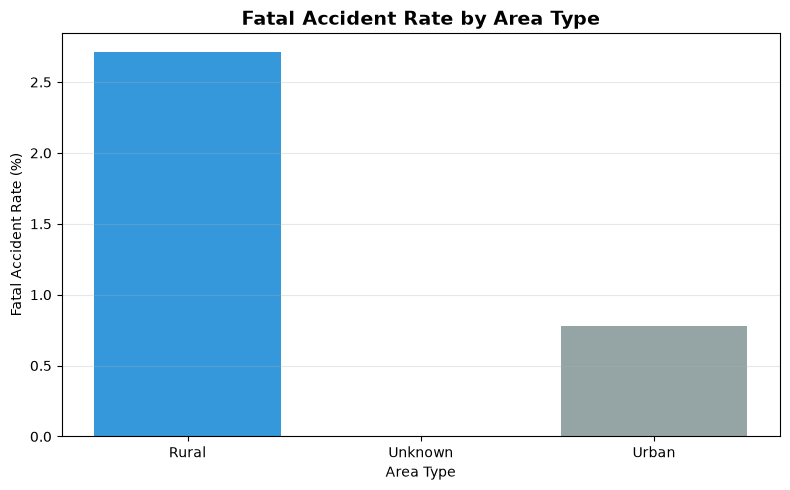

In [58]:
# Fatal Rate Chart
plt.figure(figsize=(8, 5))

plt.bar(
    fatal_rate_area.index,
    fatal_rate_area.values,
    color=["#3498DB", "#E74C3C", "#95A5A6"]
)

plt.title(
    "Fatal Accident Rate by Area Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Area Type")
plt.ylabel("Fatal Accident Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()